# Trabajo Fin de Máster
## Business Analytics aplicado a FOOD&FUN: análisis, predicción y optimización para la toma de decisiones

## Análisis predictivo de la demanda mediante técnicas de Machine Learning

**Autora:** Francisca Concha

**Máster en Business Analytics e Inteligencia de Negocio**

**Universidad Católica de Valencia**

**Curso académico 2025–2026**


# 1. Análisis Exploratorio de Datos (EDA)

## Objetivo de la fase

Una vez completado el proceso de integración y limpieza de los datos, se procede a realizar un análisis exploratorio con el fin de comprender la estructura del conjunto de datos, identificar patrones de comportamiento, detectar tendencias temporales y obtener información relevante para las siguientes fases del proyecto.

Este análisis permitirá conocer mejor el comportamiento de compra de los clientes, la evolución de la demanda de los talleres y los factores que pueden influir en la ocupación y planificación futura de las actividades ofrecidas por Food & Fun.

## 1.1 Importación de librerías

In [84]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## 1.2 Carga del dataset

In [85]:
pd.__version__

'3.0.1'

In [86]:
ruta = "/Users/fran/Desktop/UCV Master /TFM/TFM VSC/Pedidos_22_26_Completado.xlsx"

df = pd.read_excel(ruta)

print(df.shape)

(2501, 10)


In [87]:
df.head()

,Fecha Compra,Pedido #,Estado,Cliente,Tipo de cliente,Productos,Artículos vendidos,Ventas netas,Atribución,Categoría
0,2026-06-01,1024,Completado,Raquel Benito Benito,New,Tapas Españolas - 05/06/2026,1,81.0,Shopify,Tapas
1,2026-05-29,1015,Completado,Tania Zanabria,New,Curso de Arroces - 20/06/2026,1,70.0,Shopify,Arroces
2,2026-05-29,1015,Completado,Tania Zanabria,New,Curso de Arroces - 20/06/2026,1,70.0,Shopify,Arroces
3,2026-05-29,81672,Completado,Pepe Cervera,New,Curso de Arroces - 31/05/2026,1,0.0,Tarjeta Regalo (canjeado),Arroces
4,2026-05-29,1015,Completado,Felix Aranda Rodríguez,New,Paella Lovers - 06/06/2026,2,140.0,Shopify,Paella


In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2501 entries, 0 to 2500
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Fecha Compra        2501 non-null   datetime64[us]
 1   Pedido #            2501 non-null   int64         
 2   Estado              2501 non-null   str           
 3   Cliente             2501 non-null   str           
 4   Tipo de cliente     2501 non-null   str           
 5   Productos           2501 non-null   str           
 6   Artículos vendidos  2501 non-null   int64         
 7   Ventas netas        2501 non-null   float64       
 8   Atribución          2493 non-null   str           
 9   Categoría           2501 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(2), str(6)
memory usage: 413.8 KB


In [89]:
df.describe(include="all")

,Fecha Compra,Pedido #,Estado,Cliente,Tipo de cliente,Productos,Artículos vendidos,Ventas netas,Atribución,Categoría
count,2501,2.501000e+03,2501,2501,2501,2501,2501.000000,2501.000000,2493,2501
unique,NaN,NaN,3,1957,2,161,NaN,NaN,31,22
top,NaN,NaN,Completado,Paula Martinez Moreno,New,"Food & Fun, escenario culinario",NaN,NaN,Directo,Food & Fun
freq,NaN,NaN,2308,7,2087,789,NaN,NaN,767,789
mean,2024-12-16 23:57:41.815274,3.416979e+07,NaN,NaN,NaN,NaN,1.500200,108.390144,NaN,NaN
min,2022-03-28 00:00:00,1.008000e+03,NaN,NaN,NaN,NaN,-8.000000,-640.000000,NaN,NaN
25%,2024-05-06 00:00:00,4.385049e+07,NaN,NaN,NaN,NaN,1.000000,70.000000,NaN,NaN
50%,2025-02-01 00:00:00,4.386186e+07,NaN,NaN,NaN,NaN,1.000000,90.000000,NaN,NaN
75%,2025-09-28 00:00:00,4.387426e+07,NaN,NaN,NaN,NaN,2.000000,180.000000,NaN,NaN
max,2026-06-01 00:00:00,4.387844e+07,NaN,NaN,NaN,NaN,14.000000,1905.750000,NaN,NaN


In [90]:
df["Fecha Compra"] = pd.to_datetime(
    df["Fecha Compra"],
    format="%d/%m/%Y"
)

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2501 entries, 0 to 2500
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Fecha Compra        2501 non-null   datetime64[us]
 1   Pedido #            2501 non-null   int64         
 2   Estado              2501 non-null   str           
 3   Cliente             2501 non-null   str           
 4   Tipo de cliente     2501 non-null   str           
 5   Productos           2501 non-null   str           
 6   Artículos vendidos  2501 non-null   int64         
 7   Ventas netas        2501 non-null   float64       
 8   Atribución          2493 non-null   str           
 9   Categoría           2501 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(2), str(6)
memory usage: 413.8 KB


In [92]:
df["Pedido #"] = df["Pedido #"].astype(str)

In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2501 entries, 0 to 2500
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Fecha Compra        2501 non-null   datetime64[us]
 1   Pedido #            2501 non-null   str           
 2   Estado              2501 non-null   str           
 3   Cliente             2501 non-null   str           
 4   Tipo de cliente     2501 non-null   str           
 5   Productos           2501 non-null   str           
 6   Artículos vendidos  2501 non-null   int64         
 7   Ventas netas        2501 non-null   float64       
 8   Atribución          2493 non-null   str           
 9   Categoría           2501 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(1), str(7)
memory usage: 431.2 KB


In [94]:
df["Ventas netas"].apply(type).value_counts()

Ventas netas
<class 'float'>    2501
Name: count, dtype: int64

In [95]:
df[df["Ventas netas"].apply(lambda x: isinstance(x, str))]["Ventas netas"].head(20)

Series([], Name: Ventas netas, dtype: float64)

In [96]:
df["Ventas netas"] = (
    df["Ventas netas"]
    .astype(str)
    .str.replace("€", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
)

df["Ventas netas"] = pd.to_numeric(df["Ventas netas"], errors="coerce")

In [97]:
df["Ventas netas"].dtype

dtype('float64')

In [98]:
df["Ventas netas"].isna().sum()

np.int64(0)

In [99]:
df[df["Ventas netas"].isna()]

,Fecha Compra,Pedido #,Estado,Cliente,Tipo de cliente,Productos,Artículos vendidos,Ventas netas,Atribución,Categoría


In [100]:
# Pedido 43877480 → 1.905,75 €
df.loc[df["Pedido #"] == "43877480", "Ventas netas"] = 1905.75

# Pedido 43877299 → 1080 €
df.loc[df["Pedido #"] == "43877299", "Ventas netas"] = 1080.00

# Pedido 43877087 → 1260 €
df.loc[df["Pedido #"] == "43877087", "Ventas netas"] = 1260.00

In [101]:
df["Ventas netas"].isna().sum()

np.int64(0)

In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2501 entries, 0 to 2500
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Fecha Compra        2501 non-null   datetime64[us]
 1   Pedido #            2501 non-null   str           
 2   Estado              2501 non-null   str           
 3   Cliente             2501 non-null   str           
 4   Tipo de cliente     2501 non-null   str           
 5   Productos           2501 non-null   str           
 6   Artículos vendidos  2501 non-null   int64         
 7   Ventas netas        2501 non-null   float64       
 8   Atribución          2493 non-null   str           
 9   Categoría           2501 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(1), str(7)
memory usage: 431.2 KB


Tras la carga del conjunto de datos se realizó una revisión de la estructura, tipos de variables y valores faltantes. La variable de fecha fue transformada al formato datetime para facilitar el análisis temporal. Asimismo, el identificador del pedido se trató como variable categórica, mientras que la variable monetaria "Ventas netas" fue limpiada y convertida a formato numérico. Finalmente, se verificó la ausencia de valores nulos en las variables principales, obteniéndose un conjunto de datos consistente y preparado para el análisis exploratorio posterior.

# 2. Análisis Exploratorio de la Demanda
## 2.1 Estadísticas descriptivas generales

In [103]:
df[["Ventas netas", "Artículos vendidos"]].describe()

,Ventas netas,Artículos vendidos
count,2501.000000,2501.000000
mean,108.390144,1.500200
std,108.510111,1.107655
min,-640.000000,-8.000000
25%,70.000000,1.000000
50%,90.000000,1.000000
75%,180.000000,2.000000
max,1905.750000,14.000000


Se realizó un análisis descriptivo inicial de las variables cuantitativas relacionadas con las ventas. Este análisis permite conocer la distribución general de los importes facturados y del número de artículos vendidos por pedido, proporcionando una primera visión del comportamiento de compra de los clientes.

## 2.2 Distribución de los estados de los pedidos

In [104]:
df["Estado"].value_counts()

Estado
Completado     2308
Reembolsado     169
Procesando       24
Name: count, dtype: int64

<Axes: xlabel='Estado'>

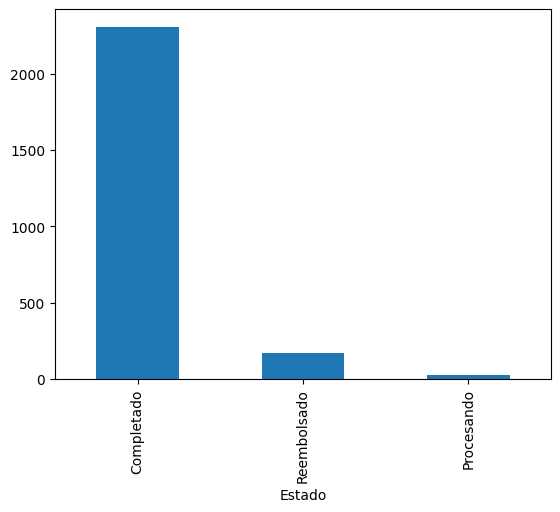

In [105]:
df["Estado"].value_counts().plot(kind="bar")

## 2.3 Análisis de clientes nuevos y recurrentes

In [106]:
df["Tipo de cliente"].value_counts()

Tipo de cliente
New          2087
Returning     414
Name: count, dtype: int64

In [107]:
df["Tipo de cliente"].value_counts(normalize=True)*100

Tipo de cliente
New          83.446621
Returning    16.553379
Name: proportion, dtype: float64

<Axes: >

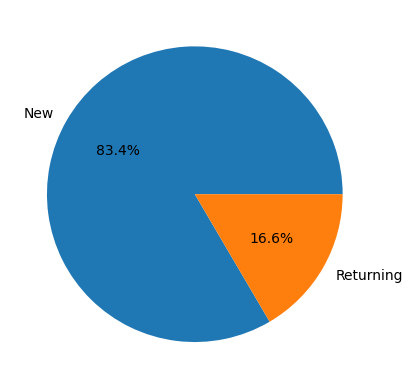

In [108]:
df["Tipo de cliente"].value_counts().plot(kind="pie", autopct="%1.1f%%")

## 2.4 Productos más vendidos

In [109]:
df["Productos"].value_counts().head(20)

Productos
Food & Fun, escenario culinario                                                          789
Tarjeta regalo                                                                           411
Tarjeta Regalo                                                                           123
Raíces                                                                                    97
Paella Lovers                                                                             82
Curso de Arroces                                                                          72
Ramen                                                                                     43
Tapas Españolas                                                                           41
Sushi                                                                                     38
Curso Cocina Coreana HAESUNG YOON ("La Taula de Yoon") - 2 Febrero 2026 18:00 - 22:00     16
Curso Cocina Japonesa RAMEN - 23 Enero 2026 18:00-22:00     

<Axes: ylabel='Productos'>

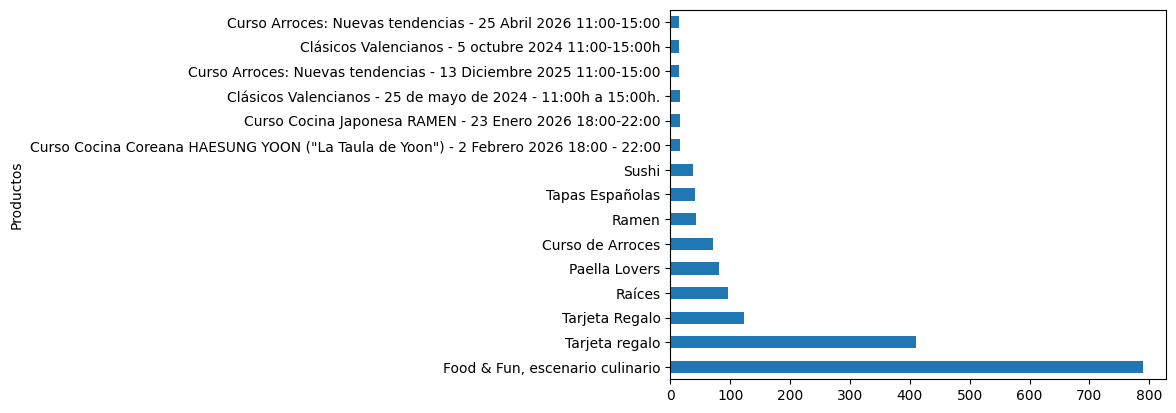

In [110]:
df["Productos"].value_counts().head(15).plot(kind="barh")

In [111]:
df["Productos"].value_counts().head(10)

Productos
Food & Fun, escenario culinario                                                          789
Tarjeta regalo                                                                           411
Tarjeta Regalo                                                                           123
Raíces                                                                                    97
Paella Lovers                                                                             82
Curso de Arroces                                                                          72
Ramen                                                                                     43
Tapas Españolas                                                                           41
Sushi                                                                                     38
Curso Cocina Coreana HAESUNG YOON ("La Taula de Yoon") - 2 Febrero 2026 18:00 - 22:00     16
Name: count, dtype: int64

In [112]:
df["Categoría"].value_counts()

Categoría
Food & Fun           789
Tarjeta Regalo       534
Arroces              196
Paella               138
Sushi                136
Ramen                120
Cocina Coreana       114
Raíces                97
Tapas                 81
Repostería            80
Cocina Valenciana     60
Pasta                 35
Mexico                34
Principiantes         21
Curry                 21
Peru                  17
Croquetas             11
Cocas Valencianas      8
Noble                  5
Otros                  2
Fermentos              1
Cocina Tailandesa      1
Name: count, dtype: int64

In [113]:
ruta_salida = "/Users/fran/Desktop/UCV Master /TFM/TFM VSC/Pedidos_22_26_Completado.xlsx"

df.to_excel(ruta_salida, index=False)

print("Excel actualizado correctamente")

Excel actualizado correctamente


In [114]:
df.columns

Index(['Fecha Compra', 'Pedido #', 'Estado', 'Cliente', 'Tipo de cliente',
       'Productos', 'Artículos vendidos', 'Ventas netas', 'Atribución',
       'Categoría'],
      dtype='str')

In [115]:
df[["Productos", "Categoría"]].head(10)

,Productos,Categoría
0,Tapas Españolas - 05/06/2026,Tapas
1,Curso de Arroces - 20/06/2026,Arroces
2,Curso de Arroces - 20/06/2026,Arroces
3,Curso de Arroces - 31/05/2026,Arroces
4,Paella Lovers - 06/06/2026,Paella
5,Paella Lovers - 06/06/2026,Paella
6,Paella Lovers - 20/06/2026,Paella
7,Tapas Españolas - 03/07/2026,Tapas
8,Curso de Arroces - 20/06/2026,Arroces
9,Tarjeta Regalo,Tarjeta Regalo


In [116]:
df["Categoría"].value_counts()

Categoría
Food & Fun           789
Tarjeta Regalo       534
Arroces              196
Paella               138
Sushi                136
Ramen                120
Cocina Coreana       114
Raíces                97
Tapas                 81
Repostería            80
Cocina Valenciana     60
Pasta                 35
Mexico                34
Principiantes         21
Curry                 21
Peru                  17
Croquetas             11
Cocas Valencianas      8
Noble                  5
Otros                  2
Fermentos              1
Cocina Tailandesa      1
Name: count, dtype: int64

In [117]:
df

,Fecha Compra,Pedido #,Estado,Cliente,Tipo de cliente,Productos,Artículos vendidos,Ventas netas,Atribución,Categoría
0,2026-06-01,1024,Completado,Raquel Benito Benito,New,Tapas Españolas - 05/06/2026,1,81.0,Shopify,Tapas
1,2026-05-29,1015,Completado,Tania Zanabria,New,Curso de Arroces - 20/06/2026,1,70.0,Shopify,Arroces
2,2026-05-29,1015,Completado,Tania Zanabria,New,Curso de Arroces - 20/06/2026,1,70.0,Shopify,Arroces
3,2026-05-29,81672,Completado,Pepe Cervera,New,Curso de Arroces - 31/05/2026,1,0.0,Tarjeta Regalo (canjeado),Arroces
4,2026-05-29,1015,Completado,Felix Aranda Rodríguez,New,Paella Lovers - 06/06/2026,2,140.0,Shopify,Paella
...,...,...,...,...,...,...,...,...,...,...
2496,2022-04-28,1337,Reembolsado,Ismael Paladines,New,"Food & Fun, escenario culinario",1,70.0,Desconocido,Food & Fun
2497,2022-04-08,1306,Completado,María Vallés Planells,New,Tarjeta regalo,2,180.0,Desconocido,Tarjeta Regalo
2498,2022-04-05,1270,Completado,jose francisco devis capilla,New,"Food & Fun, escenario culinario",1,70.0,Desconocido,Food & Fun
2499,2022-03-30,1155,Reembolsado,Juan ignacio Yague,New,"Food & Fun, escenario culinario",2,140.0,Desconocido,Food & Fun


In [118]:
df.groupby("Categoría")["Artículos vendidos"].sum().sort_values(ascending=False)

Categoría
Food & Fun           1223
Tarjeta Regalo        725
Arroces               322
Sushi                 219
Paella                216
Ramen                 209
Cocina Coreana        159
Tapas                 147
Raíces                131
Repostería             98
Cocina Valenciana      71
Pasta                  69
Mexico                 57
Principiantes          26
Curry                  22
Peru                   22
Croquetas              16
Cocas Valencianas      12
Noble                   4
Otros                   2
Fermentos               1
Cocina Tailandesa       1
Name: Artículos vendidos, dtype: int64

In [119]:
resumen_categoria = df.groupby("Categoría").agg({
    "Pedido #": "count",
    "Artículos vendidos": "sum",
    "Ventas netas": "sum"
}).sort_values("Artículos vendidos", ascending=False)

resumen_categoria

,Pedido #,Artículos vendidos,Ventas netas
Categoría,,,
Food & Fun,789,1223,82770.00
Tarjeta Regalo,534,725,64175.00
Arroces,196,322,20105.00
Sushi,136,219,17000.00
Paella,138,216,13420.00
Ramen,120,209,11252.00
Cocina Coreana,114,159,12701.00
Tapas,81,147,11067.75
Raíces,97,131,9930.00


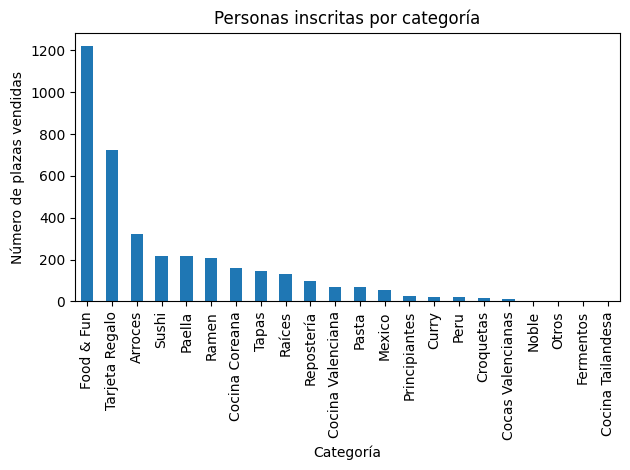

In [120]:
import matplotlib.pyplot as plt

personas = (
    df.groupby("Categoría")["Artículos vendidos"]
      .sum()
      .sort_values(ascending=False)
)

personas.plot(kind="bar")

plt.title("Personas inscritas por categoría")
plt.xlabel("Categoría")
plt.ylabel("Número de plazas vendidas")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Interpretación de la demanda por categorías

Con el objetivo de facilitar el análisis de la demanda, los productos individuales fueron agrupados en categorías homogéneas según la temática principal de cada curso o experiencia gastronómica. Esta transformación permitió reducir la dispersión generada por las múltiples ediciones de un mismo curso celebradas en fechas diferentes y obtener una visión más agregada de las preferencias de los clientes.

Posteriormente, se calculó el número total de plazas vendidas por categoría mediante la variable *Artículos vendidos*, lo que permitió identificar las temáticas con mayor demanda dentro de la oferta formativa de Food & Fun. Este análisis constituye una primera aproximación al comportamiento de los consumidores y sirve como base para la construcción de modelos predictivos posteriores.

Se decidió mantener la categoría **Food & Fun** dentro del análisis de demanda, a pesar de que parte de estos registros no contienen información detallada sobre la fecha de realización del curso. La razón principal es que el objetivo de este notebook es estudiar el comportamiento de compra de los clientes y la evolución temporal de la demanda. En este contexto, la variable relevante es la fecha de compra, información que sí está disponible para estos registros.

Además, la categoría Food & Fun representa una proporción significativa de las ventas totales, por lo que su eliminación podría introducir sesgos en el análisis descriptivo y en la estimación de la demanda agregada. No obstante, en fases posteriores del proyecto orientadas a la predicción de ocupación de talleres y a la optimización del calendario de cursos, se evaluará la conveniencia de excluir aquellos registros que no dispongan de una fecha de celebración claramente identificable.


## 2.5 Evolución temporal de la demanda


In [121]:
df["Año"] = df["Fecha Compra"].dt.year
df["Mes"] = df["Fecha Compra"].dt.month

In [122]:
pedidos_mes = (
    df.groupby(["Año","Mes"])
      .size()
      .reset_index(name="Pedidos")
)

pedidos_mes.head()

,Año,Mes,Pedidos
0,2022,3,2
1,2022,4,3
2,2022,5,1
3,2022,6,1
4,2022,9,10


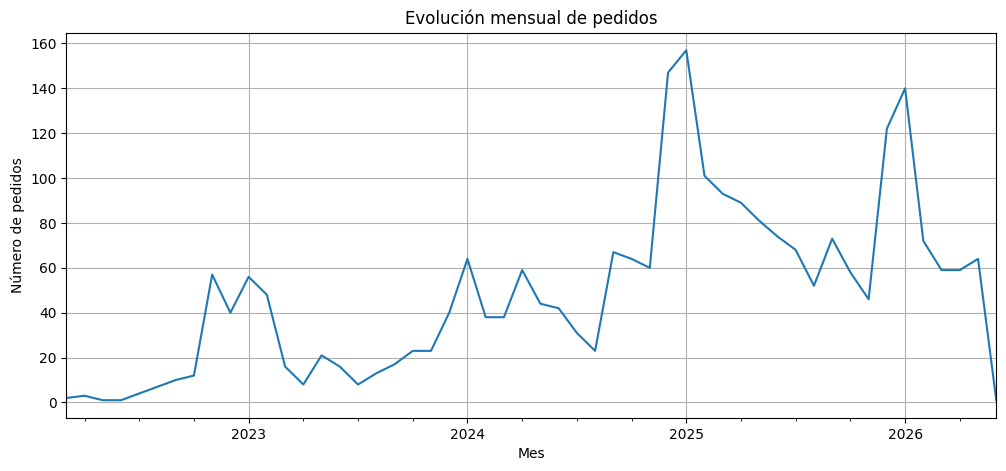

In [123]:
import matplotlib.pyplot as plt

ventas_mes = (
    df.groupby(df["Fecha Compra"].dt.to_period("M"))
      .size()
)

ventas_mes.plot(figsize=(12,5))

plt.title("Evolución mensual de pedidos")
plt.ylabel("Número de pedidos")
plt.xlabel("Mes")
plt.grid(True)
plt.show()

## 2.6 Ingresos por mes

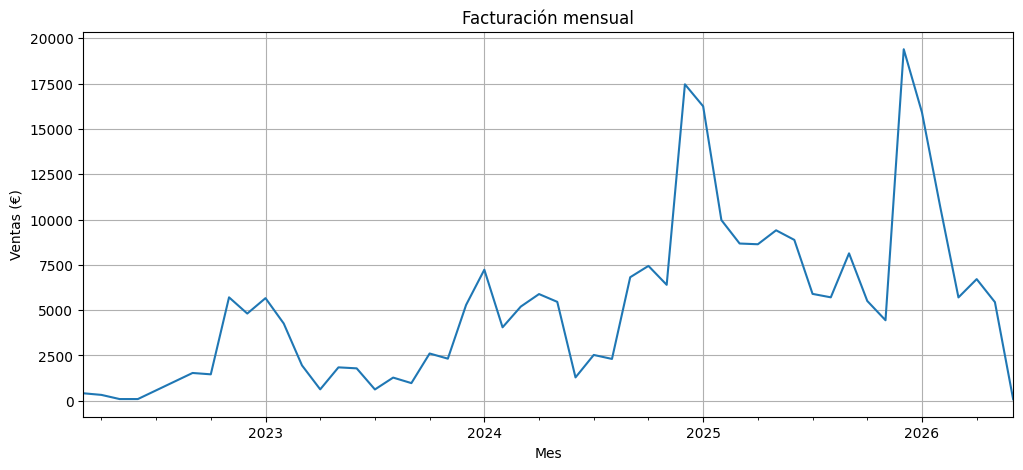

In [124]:
facturacion_mes = (
    df.groupby(df["Fecha Compra"].dt.to_period("M"))
      ["Ventas netas"]
      .sum()
)

facturacion_mes.plot(figsize=(12,5))

plt.title("Facturación mensual")
plt.ylabel("Ventas (€)")
plt.xlabel("Mes")
plt.grid(True)
plt.show()

## 2.7 Clientes nuevos vs recurrentes

In [125]:
# 1. Distribución de clientes

df["Tipo de cliente"].value_counts()

Tipo de cliente
New          2087
Returning     414
Name: count, dtype: int64

In [126]:
(
    df["Tipo de cliente"]
    .value_counts(normalize=True)
    * 100
).round(2)

Tipo de cliente
New          83.45
Returning    16.55
Name: proportion, dtype: float64

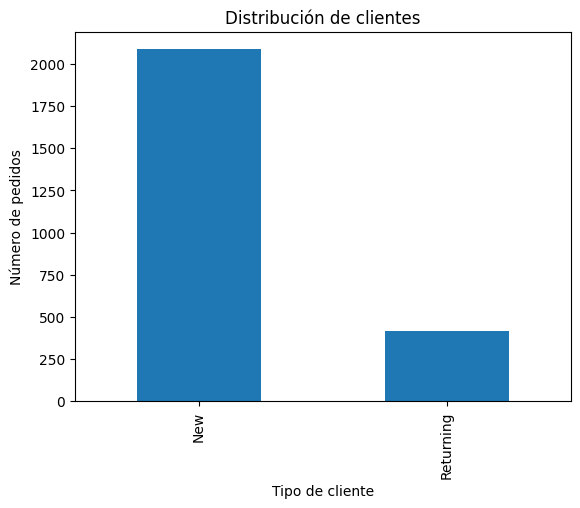

In [127]:
import matplotlib.pyplot as plt

df["Tipo de cliente"].value_counts().plot(
    kind="bar"
)

plt.title("Distribución de clientes")
plt.xlabel("Tipo de cliente")
plt.ylabel("Número de pedidos")
plt.show()

In [128]:
df.groupby("Tipo de cliente")["Ventas netas"].sum()

Tipo de cliente
New          253849.75
Returning     17234.00
Name: Ventas netas, dtype: float64

In [129]:
df.groupby("Tipo de cliente")["Ventas netas"].mean()

Tipo de cliente
New          121.633805
Returning     41.628019
Name: Ventas netas, dtype: float64

Sin contar tarjetas regalo canjeadas. Venta neta = 0

In [130]:
df_ventas = df[df["Ventas netas"] > 0]

In [131]:
df_ventas.groupby("Tipo de cliente")["Ventas netas"].mean()

Tipo de cliente
New          136.380102
Returning    112.802372
Name: Ventas netas, dtype: float64

In [132]:
df.groupby("Tipo de cliente")["Artículos vendidos"].mean()

Tipo de cliente
New          1.597508
Returning    1.009662
Name: Artículos vendidos, dtype: float64

In [133]:
df_sin_canjeos = df[df["Ventas netas"] > 0]

ticket_medio = df_sin_canjeos["Ventas netas"].mean()

print(f"Ticket medio: {ticket_medio:.2f} €")

Ticket medio: 133.56 €


In [134]:
df_sin_canjeos["Ventas netas"].describe()

count    2115.000000
mean      133.559693
std        95.140480
min         5.000000
25%        90.000000
50%        90.000000
75%       180.000000
max      1905.750000
Name: Ventas netas, dtype: float64

Para el cálculo del ticket medio se excluyeron únicamente los registros con ventas netas iguales a cero euros. Estos casos corresponden al canje de tarjetas regalo previamente adquiridas y no representan nuevas transacciones económicas. Por tanto, su inclusión habría infraestimado el valor real del gasto por pedido. El resto de categorías, incluidas las tarjetas regalo vendidas y los productos asociados a Food & Fun, se mantuvieron en el análisis al constituir ventas efectivas generadoras de ingresos.

El análisis de clientes nuevos y recurrentes muestra que la mayor parte de los ingresos procede de clientes nuevos, reflejando la capacidad de la empresa para captar demanda de forma continua. No obstante, tras excluir los canjeos de tarjetas regalo (ventas netas iguales a cero), se observa que el gasto medio de los clientes recurrentes se aproxima al de los nuevos, lo que evidencia un comportamiento de compra similar entre ambos segmentos. Este resultado pone de manifiesto la importancia de las estrategias de fidelización, dado que los clientes recurrentes mantienen un elevado valor económico para la empresa.

## 2.8 Evolución temporal de la demanda


In [135]:
pedidos_mes = df.groupby(
    df["Fecha Compra"].dt.to_period("M")
).size()

pedidos_mes

Fecha Compra
2022-03      2
2022-04      3
2022-05      1
2022-06      1
2022-09     10
2022-10     12
2022-11     57
2022-12     40
2023-01     56
2023-02     48
2023-03     16
2023-04      8
2023-05     21
2023-06     16
2023-07      8
2023-08     13
2023-09     17
2023-10     23
2023-11     23
2023-12     40
2024-01     64
2024-02     38
2024-03     38
2024-04     59
2024-05     44
2024-06     42
2024-07     31
2024-08     23
2024-09     67
2024-10     64
2024-11     60
2024-12    147
2025-01    157
2025-02    101
2025-03     93
2025-04     89
2025-05     81
2025-06     74
2025-07     68
2025-08     52
2025-09     73
2025-10     58
2025-11     46
2025-12    122
2026-01    140
2026-02     72
2026-03     59
2026-04     59
2026-05     64
2026-06      1
Freq: M, dtype: int64

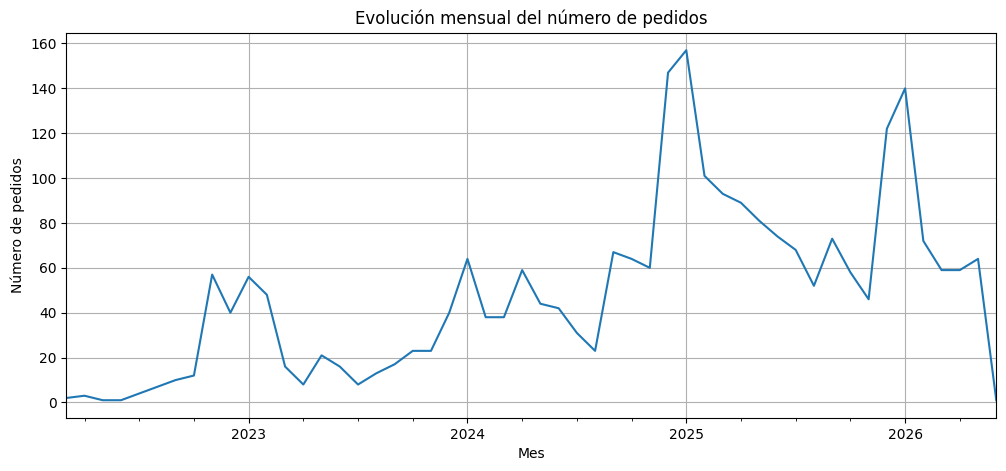

In [136]:
import matplotlib.pyplot as plt

pedidos_mes.plot(figsize=(12,5))

plt.title("Evolución mensual del número de pedidos")
plt.xlabel("Mes")
plt.ylabel("Número de pedidos")
plt.grid(True)

plt.show()

Con el objetivo de identificar tendencias temporales y posibles patrones estacionales, se analizó la evolución mensual del número de pedidos registrados entre 2022 y 2026. Este análisis permite detectar periodos de mayor y menor demanda, así como evaluar la existencia de crecimiento sostenido o fluctuaciones estacionales relevantes para el posterior desarrollo de modelos predictivos.

### 2.8.2 Evolución de la facturación mensual

In [137]:
ventas_mes = df.groupby(
    df["Fecha Compra"].dt.to_period("M")
)["Ventas netas"].sum()

ventas_mes

Fecha Compra
2022-03      410.00
2022-04      320.00
2022-05       90.00
2022-06       90.00
2022-09     1530.00
2022-10     1455.00
2022-11     5705.00
2022-12     4810.00
2023-01     5660.00
2023-02     4260.00
2023-03     1950.00
2023-04      625.00
2023-05     1840.00
2023-06     1785.00
2023-07      620.00
2023-08     1275.00
2023-09      970.00
2023-10     2605.00
2023-11     2320.00
2023-12     5285.00
2024-01     7230.00
2024-02     4050.00
2024-03     5195.00
2024-04     5885.00
2024-05     5455.00
2024-06     1285.00
2024-07     2525.00
2024-08     2305.00
2024-09     6815.00
2024-10     7440.00
2024-11     6396.00
2024-12    17463.00
2025-01    16250.00
2025-02     9970.00
2025-03     8675.00
2025-04     8635.00
2025-05     9405.00
2025-06     8875.00
2025-07     5895.00
2025-08     5705.00
2025-09     8133.00
2025-10     5505.00
2025-11     4440.00
2025-12    19400.00
2026-01    15910.00
2026-02    10705.75
2026-03     5700.00
2026-04     6710.00
2026-05     5440.00
2026-06

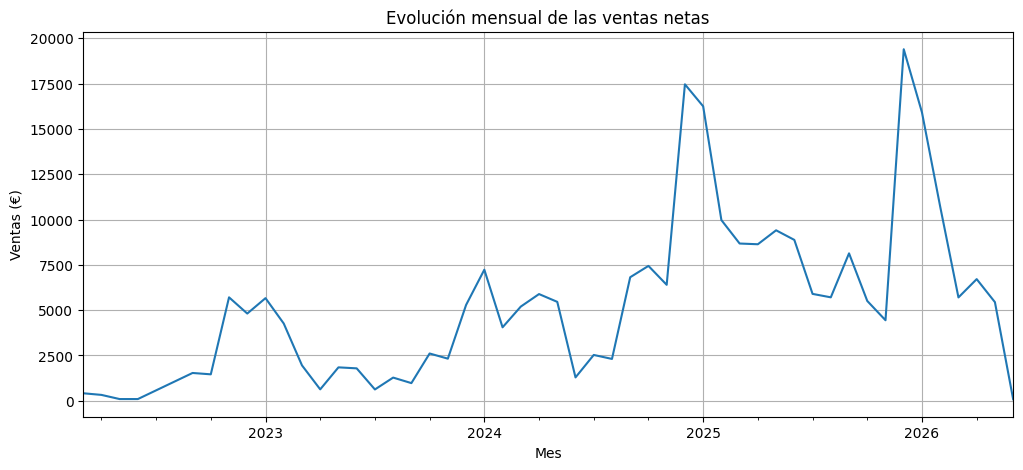

In [138]:
ventas_mes.plot(figsize=(12,5))

plt.title("Evolución mensual de las ventas netas")
plt.xlabel("Mes")
plt.ylabel("Ventas (€)")
plt.grid(True)

plt.show()

Además del volumen de pedidos, se analizó la evolución temporal de las ventas netas agregadas por mes. Este indicador permite evaluar la capacidad de generación de ingresos de la empresa a lo largo del tiempo y detectar posibles diferencias entre la evolución de la demanda y la facturación obtenida.

### 2.8.3 Identificación de los mejores y peores meses


In [139]:
pedidos_mes.sort_values(ascending=False).head(10)

Fecha Compra
2025-01    157
2024-12    147
2026-01    140
2025-12    122
2025-02    101
2025-03     93
2025-04     89
2025-05     81
2025-06     74
2025-09     73
Freq: M, dtype: int64

In [140]:
pedidos_mes.sort_values().head(10)

Fecha Compra
2026-06     1
2022-06     1
2022-05     1
2022-03     2
2022-04     3
2023-04     8
2023-07     8
2022-09    10
2022-10    12
2023-08    13
Freq: M, dtype: int64

In [141]:
ventas_mes.sort_values(ascending=False).head(10)

Fecha Compra
2025-12    19400.00
2024-12    17463.00
2025-01    16250.00
2026-01    15910.00
2026-02    10705.75
2025-02     9970.00
2025-05     9405.00
2025-06     8875.00
2025-03     8675.00
2025-04     8635.00
Freq: M, Name: Ventas netas, dtype: float64

In [142]:
ventas_mes.sort_values().head(10)

Fecha Compra
2026-06      81.0
2022-05      90.0
2022-06      90.0
2022-04     320.0
2022-03     410.0
2023-07     620.0
2023-04     625.0
2023-09     970.0
2023-08    1275.0
2024-06    1285.0
Freq: M, Name: Ventas netas, dtype: float64

### 2.8.4 Número de pedidos por mes del año

In [143]:
pedidos_mes_anio = df.groupby(
    df["Fecha Compra"].dt.month
).size()

pedidos_mes_anio

Fecha Compra
1     417
2     259
3     208
4     218
5     211
6     134
7     107
8      88
9     167
10    157
11    186
12    349
dtype: int64

In [144]:
# Cambiar números por nombres

meses = {
    1:"Enero", 2:"Febrero", 3:"Marzo", 4:"Abril",
    5:"Mayo", 6:"Junio", 7:"Julio", 8:"Agosto",
    9:"Septiembre", 10:"Octubre", 11:"Noviembre", 12:"Diciembre"
}

pedidos_mes_anio.index = pedidos_mes_anio.index.map(meses)

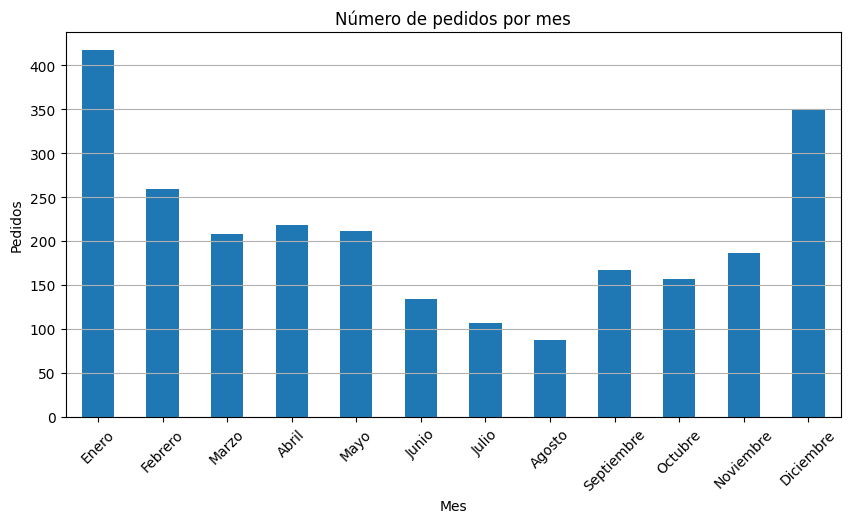

In [145]:
import matplotlib.pyplot as plt

pedidos_mes_anio.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Número de pedidos por mes")
plt.xlabel("Mes")
plt.ylabel("Pedidos")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

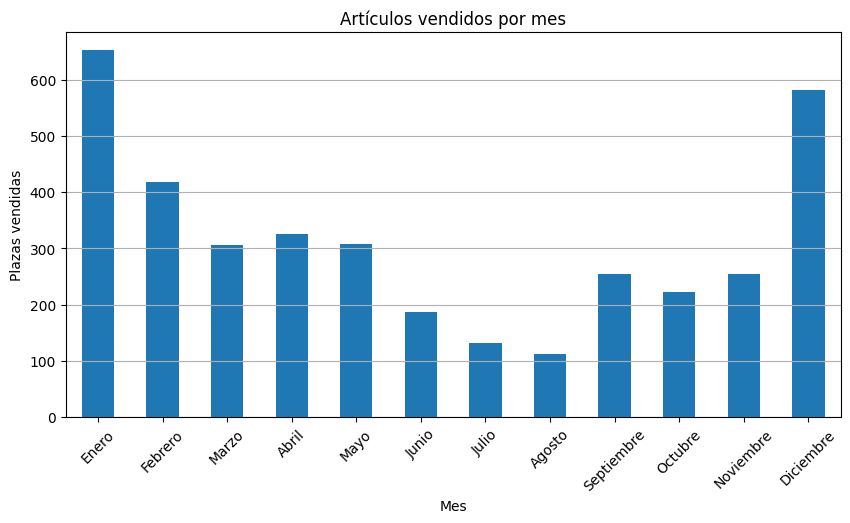

In [146]:
# Artículos vendidos por mes

articulos_mes = df.groupby(
    df["Fecha Compra"].dt.month
)["Artículos vendidos"].sum()

articulos_mes.index = articulos_mes.index.map(meses)

articulos_mes.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Artículos vendidos por mes")
plt.xlabel("Mes")
plt.ylabel("Plazas vendidas")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

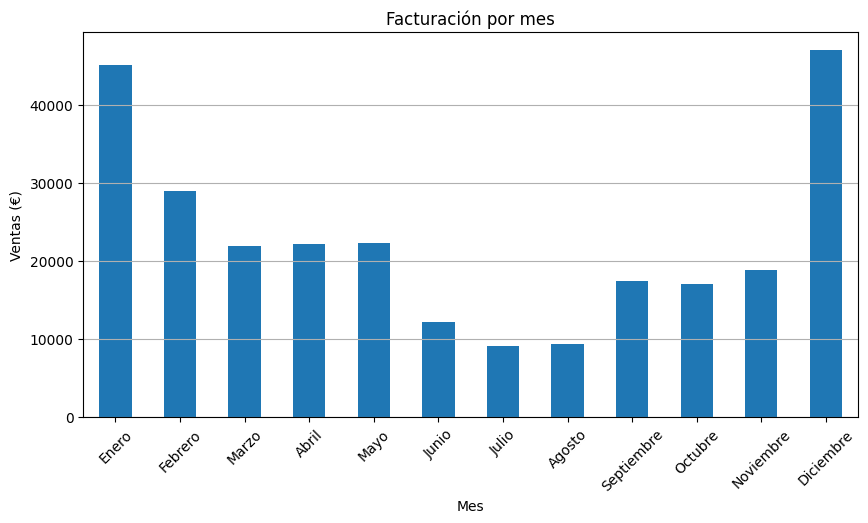

In [147]:
# facturación por mes
ventas_mes = df.groupby(
    df["Fecha Compra"].dt.month
)["Ventas netas"].sum()

ventas_mes.index = ventas_mes.index.map(meses)

ventas_mes.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Facturación por mes")
plt.xlabel("Mes")
plt.ylabel("Ventas (€)")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

## 2.9 Análisis de la demanda por día de la semana

In [148]:
df["Dia_semana"] = df["Fecha Compra"].dt.day_name()

In [149]:
dias = {
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miércoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

df["Dia_semana"] = df["Dia_semana"].map(dias)

In [150]:
pedidos_dia = df["Dia_semana"].value_counts().reindex([
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
])

pedidos_dia

Dia_semana
Lunes        402
Martes       409
Miércoles    404
Jueves       370
Viernes      378
Sábado       258
Domingo      280
Name: count, dtype: int64

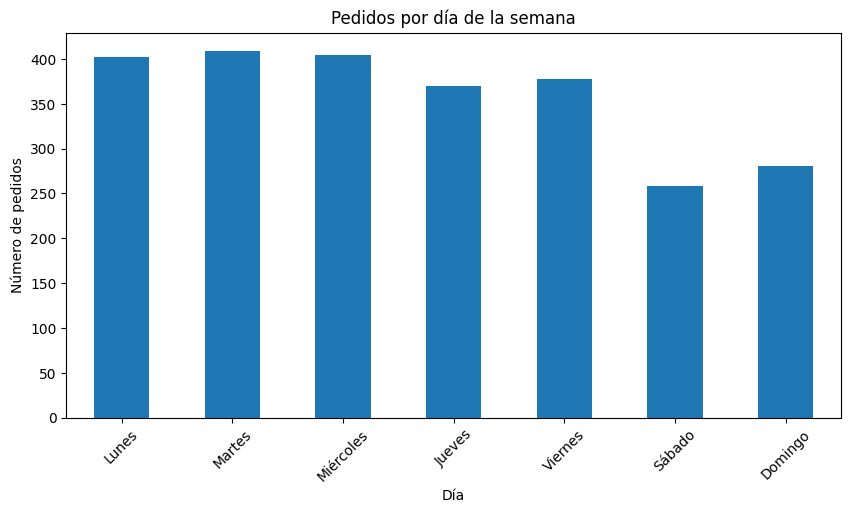

In [151]:
import matplotlib.pyplot as plt

pedidos_dia.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Pedidos por día de la semana")
plt.xlabel("Día")
plt.ylabel("Número de pedidos")
plt.xticks(rotation=45)

plt.show()

## 2.10 Categorías por estacionalidad

In [152]:
df["Categoría"].value_counts()

Categoría
Food & Fun           789
Tarjeta Regalo       534
Arroces              196
Paella               138
Sushi                136
Ramen                120
Cocina Coreana       114
Raíces                97
Tapas                 81
Repostería            80
Cocina Valenciana     60
Pasta                 35
Mexico                34
Principiantes         21
Curry                 21
Peru                  17
Croquetas             11
Cocas Valencianas      8
Noble                  5
Otros                  2
Fermentos              1
Cocina Tailandesa      1
Name: count, dtype: int64

In [153]:
df.groupby("Categoría")["Ventas netas"].sum().sort_values(
    ascending=False
)

Categoría
Food & Fun           82770.00
Tarjeta Regalo       64175.00
Arroces              20105.00
Sushi                17000.00
Paella               13420.00
Cocina Coreana       12701.00
Ramen                11252.00
Tapas                11067.75
Raíces                9930.00
Cocina Valenciana     5440.00
Pasta                 5320.00
Repostería            5190.00
Principiantes         4403.00
Mexico                3770.00
Peru                  1530.00
Curry                 1045.00
Cocas Valencianas      865.00
Croquetas              820.00
Noble                  100.00
Cocina Tailandesa       90.00
Otros                   90.00
Fermentos                0.00
Name: Ventas netas, dtype: float64

In [154]:
df.groupby("Categoría")["Artículos vendidos"].sum().sort_values(
    ascending=False
)

Categoría
Food & Fun           1223
Tarjeta Regalo        725
Arroces               322
Sushi                 219
Paella                216
Ramen                 209
Cocina Coreana        159
Tapas                 147
Raíces                131
Repostería             98
Cocina Valenciana      71
Pasta                  69
Mexico                 57
Principiantes          26
Curry                  22
Peru                   22
Croquetas              16
Cocas Valencianas      12
Noble                   4
Otros                   2
Fermentos               1
Cocina Tailandesa       1
Name: Artículos vendidos, dtype: int64

In [155]:
top_categorias = [
    "Tarjeta Regalo",
    "Arroces",
    "Sushi",
    "Paella",
    "Ramen",
    "Cocina Coreana",
    "Tapas",
    "Raíces",
    "Repostería",
    "Cocina Valenciana"
]

In [156]:
demanda_categoria = (
    df[df["Categoría"].isin(top_categorias)]
    .groupby([
        df["Fecha Compra"].dt.to_period("M"),
        "Categoría"
    ])
    .size()
    .unstack(fill_value=0)
)

demanda_categoria.head()

Categoría,Arroces,Cocina Coreana,Cocina Valenciana,Paella,Ramen,Raíces,Repostería,Sushi,Tapas,Tarjeta Regalo
Fecha Compra,,,,,,,,,,
2022-04,0,0,0,0,0,0,0,0,0,1
2022-06,0,0,0,0,0,0,0,0,0,1
2022-09,0,0,0,0,0,0,0,0,0,3
2022-10,0,0,0,0,0,0,0,0,0,3
2022-11,0,0,0,0,0,0,0,0,0,4


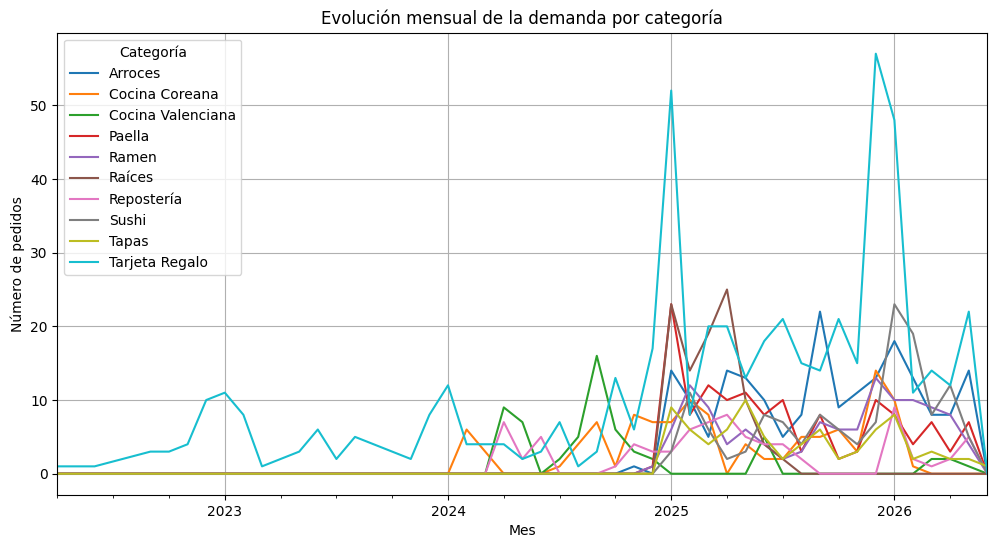

In [157]:
demanda_categoria.plot(
    figsize=(12,6)
)

plt.title("Evolución mensual de la demanda por categoría")
plt.xlabel("Mes")
plt.ylabel("Número de pedidos")
plt.grid(True)

plt.show()

Las tarjetas regalo constituyen una parte importante de la actividad comercial de Food & Fun, por lo que se incluyen en el análisis general de demanda. No obstante, para analizar las preferencias gastronómicas de los clientes también se estudian de forma independiente las categorías asociadas a cursos y experiencias culinarias.

In [158]:
top_categorias = [
    "Arroces",
    "Sushi",
    "Repostería",
    "Paella",
    "Tapas"
]

In [159]:
demanda_categoria = (
    df[df["Categoría"].isin(top_categorias)]
    .groupby([
        df["Fecha Compra"].dt.to_period("M"),
        "Categoría"
    ])
    .size()
    .unstack(fill_value=0)
)

demanda_categoria.head()

Categoría,Arroces,Paella,Repostería,Sushi,Tapas
Fecha Compra,,,,,
2024-04,0,0,7,0,0
2024-05,0,0,2,0,0
2024-06,0,0,5,0,0
2024-10,0,0,1,0,0
2024-11,1,0,4,0,0


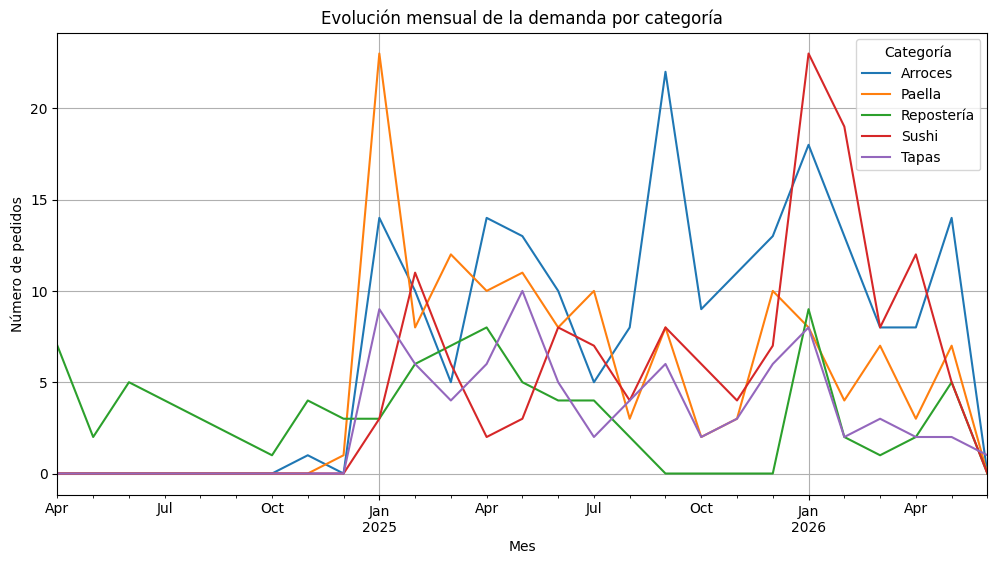

In [160]:
demanda_categoria.plot(
    figsize=(12,6)
)

plt.title("Evolución mensual de la demanda por categoría")
plt.xlabel("Mes")
plt.ylabel("Número de pedidos")
plt.grid(True)

plt.show()

## 2.11 Identificación de meses fuertes y débiles

In [161]:
pedidos_mes_anio.sort_values(ascending=False)

Fecha Compra
Enero         417
Diciembre     349
Febrero       259
Abril         218
Mayo          211
Marzo         208
Noviembre     186
Septiembre    167
Octubre       157
Junio         134
Julio         107
Agosto         88
dtype: int64

El análisis temporal revela la existencia de patrones estacionales en la demanda de los cursos gastronómicos. Determinados meses concentran un volumen significativamente superior de pedidos, mientras que otros presentan una actividad reducida. Esta evidencia justifica la aplicación de modelos predictivos capaces de anticipar la demanda futura y facilitar la planificación de recursos y actividades.

## 2.12 Análisis de tarjetas regalo

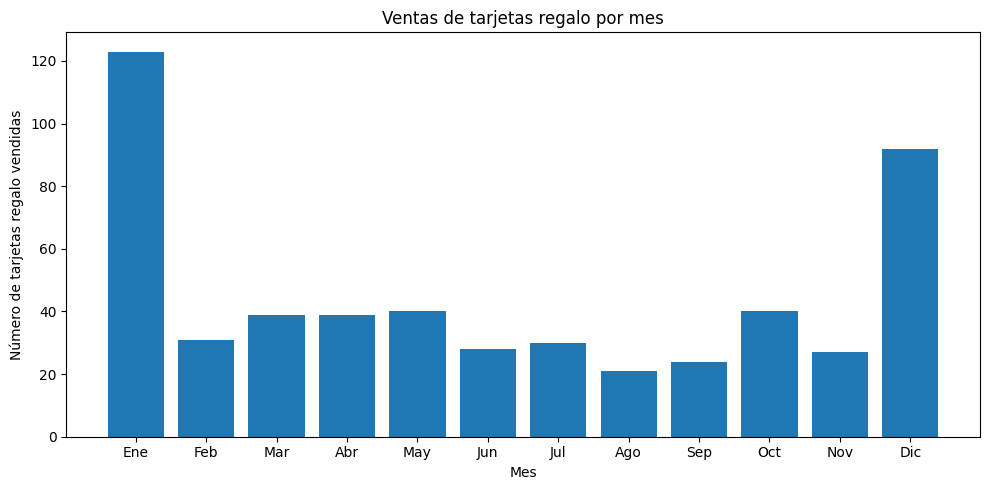

In [162]:
df_tarjetas = df[df["Categoría"] == "Tarjeta Regalo"]

tarjetas_mes = (
    df_tarjetas.groupby("Mes")
    .size()
    .reindex(range(1,13), fill_value=0)
)

meses = [
    "Ene","Feb","Mar","Abr","May","Jun",
    "Jul","Ago","Sep","Oct","Nov","Dic"
]

plt.figure(figsize=(10,5))

plt.bar(meses, tarjetas_mes)

plt.title("Ventas de tarjetas regalo por mes")
plt.xlabel("Mes")
plt.ylabel("Número de tarjetas regalo vendidas")

plt.tight_layout()
plt.show()

# 3. Preparación de los datos para la predicción de demanda

## 3.1 Construcción de la serie temporal

In [163]:
demanda_mensual = (
    df.groupby(
        df["Fecha Compra"].dt.to_period("M")
    )
    .size()
    .reset_index(name="Pedidos")
)

demanda_mensual.head()

,Fecha Compra,Pedidos
0,2022-03,2
1,2022-04,3
2,2022-05,1
3,2022-06,1
4,2022-09,10


In [164]:
demanda_mensual["Fecha"] = demanda_mensual[
    "Fecha Compra"
].astype(str)

demanda_mensual["Fecha"] = pd.to_datetime(
    demanda_mensual["Fecha"]
)

In [165]:
demanda_mensual.head()

,Fecha Compra,Pedidos,Fecha
0,2022-03,2,2022-03-01
1,2022-04,3,2022-04-01
2,2022-05,1,2022-05-01
3,2022-06,1,2022-06-01
4,2022-09,10,2022-09-01


## 3.2 Visualización de la serie temporal

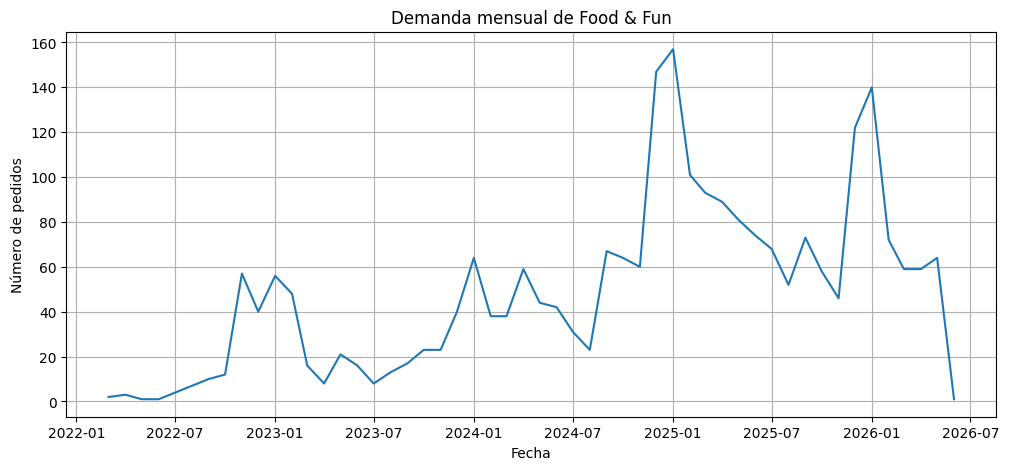

In [166]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    demanda_mensual["Fecha"],
    demanda_mensual["Pedidos"]
)

plt.title("Demanda mensual de Food & Fun")
plt.xlabel("Fecha")
plt.ylabel("Número de pedidos")
plt.grid(True)

plt.show()

Con el objetivo de construir un modelo predictivo, se agregaron los pedidos a nivel mensual, obteniendo una serie temporal que representa la evolución de la demanda a lo largo del período de estudio. Esta agregación permite identificar tendencias, ciclos y posibles patrones estacionales que serán utilizados posteriormente en el proceso de predicción.

## 3.3 Creación de variables temporales

In [167]:
demanda_mensual["Año"] = demanda_mensual[
    "Fecha"
].dt.year

demanda_mensual["Mes"] = demanda_mensual[
    "Fecha"
].dt.month

In [168]:
demanda_mensual.head()

,Fecha Compra,Pedidos,Fecha,Año,Mes
0,2022-03,2,2022-03-01,2022,3
1,2022-04,3,2022-04-01,2022,4
2,2022-05,1,2022-05-01,2022,5
3,2022-06,1,2022-06-01,2022,6
4,2022-09,10,2022-09-01,2022,9


## 3.4 Análisis de correlación temporal

In [169]:
demanda_mensual.groupby("Mes")["Pedidos"].mean()

Mes
1     104.250000
2      64.750000
3      41.600000
4      43.600000
5      42.200000
6      26.800000
7      35.666667
8      29.333333
9      41.750000
10     39.250000
11     46.500000
12     87.250000
Name: Pedidos, dtype: float64

Con el objetivo de cuantificar la estacionalidad observada en los análisis anteriores, se calculó el número medio de pedidos para cada mes del año considerando todo el periodo analizado.

Los resultados muestran que enero es el mes con mayor demanda media (104,25 pedidos), seguido por diciembre (87,25 pedidos) y febrero (64,75 pedidos). Por el contrario, los meses de junio (26,80 pedidos), agosto (29,33 pedidos) y julio (35,67 pedidos) presentan los niveles de actividad más reducidos.

Estos resultados confirman la existencia de un patrón estacional anual claramente definido. Los meses asociados al periodo navideño y posterior concentran una mayor actividad comercial, mientras que los meses estivales registran una menor demanda. Este comportamiento deberá ser considerado en la fase de modelización, incorporando variables temporales que permitan capturar dichos efectos estacionales.

## ANOVA por meses

Comprobar si la demanda media cambia significativamente entre meses.

Hipótesis:

H0: todos los meses tienen la misma demanda media.
H1: al menos un mes tiene una demanda diferente.

In [170]:
from scipy.stats import f_oneway

grupos = [
    demanda_mensual[demanda_mensual["Mes"] == mes]["Pedidos"]
    for mes in range(1, 13)
]

f_stat, p_valor = f_oneway(*grupos)

print("F =", f_stat)
print("p =", p_valor)

F = 1.7958558609395967
p = 0.0893758428287652


Los resultados del ANOVA muestran indicios de diferencias en la demanda entre meses (p = 0,089), aunque dichas diferencias no alcanzan el nivel de significación estadística del 5%. No obstante, el análisis gráfico realizado previamente revela patrones estacionales que sugieren la existencia de comportamientos recurrentes en determinados periodos del año.

## 3.5 Análisis de la estacionalidad de la demanda

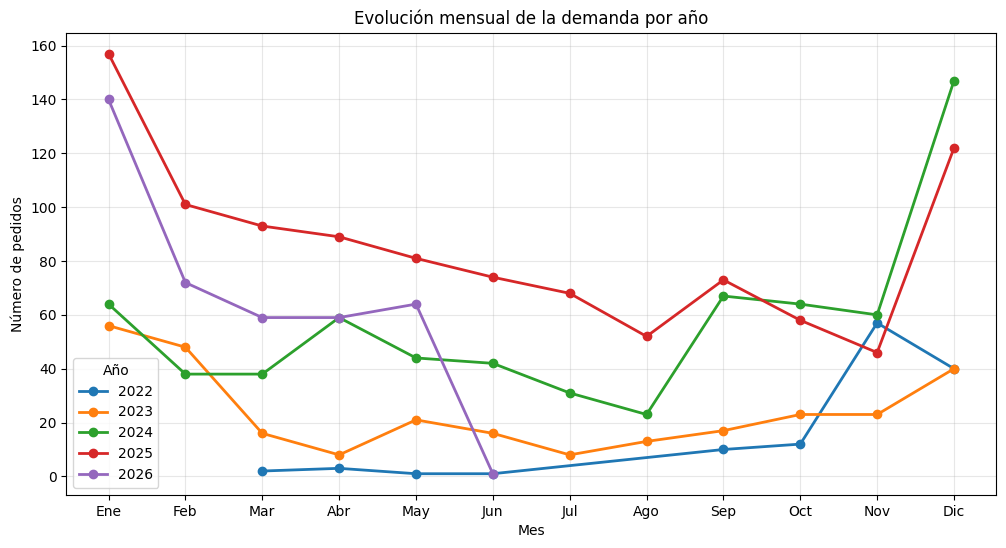

In [171]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for año in sorted(demanda_mensual["Año"].unique()):
    datos = demanda_mensual[demanda_mensual["Año"] == año]

    plt.plot(
        datos["Mes"],
        datos["Pedidos"],
        marker="o",
        linewidth=2,
        label=str(año)
    )

plt.xticks(
    range(1, 13),
    ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
     "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
)

plt.xlabel("Mes")
plt.ylabel("Número de pedidos")
plt.title("Evolución mensual de la demanda por año")
plt.legend(title="Año")
plt.grid(alpha=0.3)

plt.show()

In [172]:
tabla_estacionalidad = demanda_mensual.pivot_table(
    values="Pedidos",
    index="Mes",
    columns="Año",
    aggfunc="sum"
)

tabla_estacionalidad

Año,2022,2023,2024,2025,2026
Mes,,,,,
1,NaN,56.0,64.0,157.0,140.0
2,NaN,48.0,38.0,101.0,72.0
3,2.0,16.0,38.0,93.0,59.0
4,3.0,8.0,59.0,89.0,59.0
5,1.0,21.0,44.0,81.0,64.0
6,1.0,16.0,42.0,74.0,1.0
7,NaN,8.0,31.0,68.0,NaN
8,NaN,13.0,23.0,52.0,NaN
9,10.0,17.0,67.0,73.0,NaN


## 3.6 Distribución de la demanda por mes y año

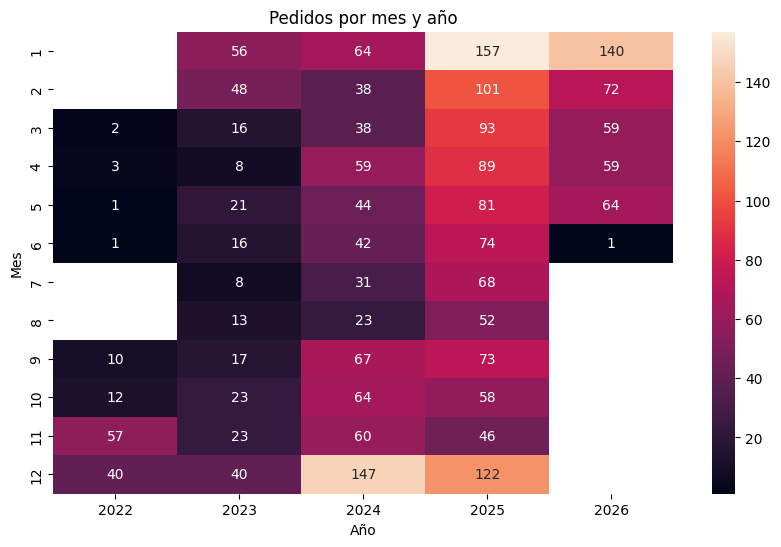

In [173]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    tabla_estacionalidad,
    annot=True,
    fmt=".0f"
)

plt.title("Pedidos por mes y año")
plt.show()

## 3.7 Descomposición temporal de la serie

Con el objetivo de identificar los componentes estructurales de la demanda, se realiza una descomposición aditiva de la serie temporal. Este análisis permite separar la evolución observada en tres componentes: tendencia, estacionalidad y residuo. De este modo, es posible evaluar la existencia de patrones recurrentes y variaciones sistemáticas que puedan ser aprovechadas posteriormente por los modelos predictivos.

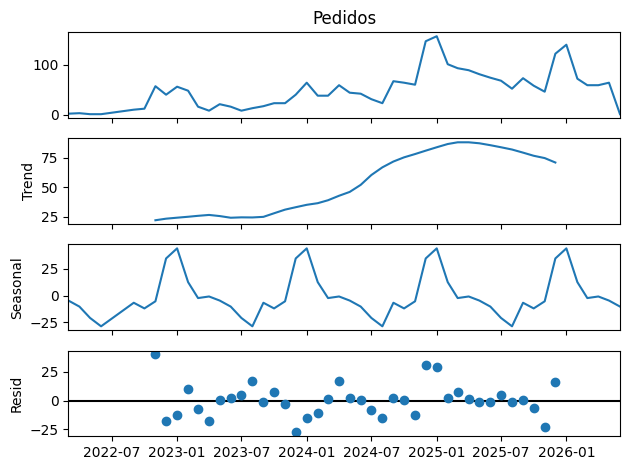

In [174]:
from statsmodels.tsa.seasonal import seasonal_decompose

serie = demanda_mensual.set_index("Fecha")["Pedidos"]

resultado = seasonal_decompose(
    serie,
    model="additive",
    period=12
)

resultado.plot();

## 3.8 Análisis de dependencia temporal (Lag Plot)

El gráfico de retardo (Lag Plot) permite analizar la dependencia entre observaciones consecutivas de la serie temporal. Si existe una relación clara entre los valores actuales y los inmediatamente anteriores, los modelos predictivos basados en retardos temporales podrán capturar parte de la dinámica de la demanda.

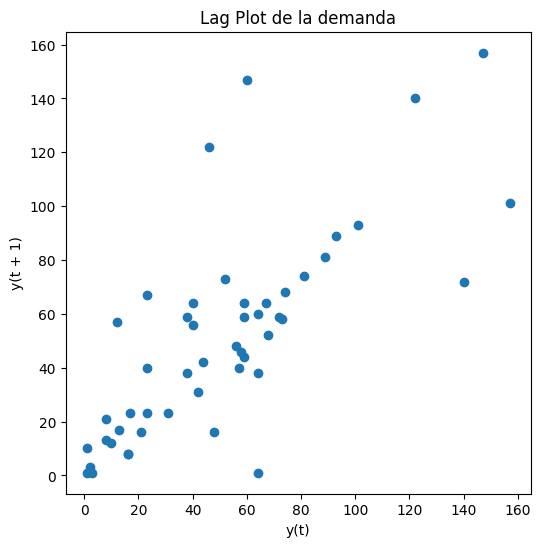

In [175]:
from pandas.plotting import lag_plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

lag_plot(serie)

plt.title("Lag Plot de la demanda")
plt.show()

## Conclusión del apartado

La preparación de la serie temporal ha permitido identificar varios patrones relevantes para la futura construcción del modelo predictivo de demanda.

En primer lugar, la evolución mensual de los pedidos muestra una tendencia creciente durante el periodo analizado. Mientras que en 2022 y 2023 la actividad era relativamente reducida, durante 2024 se observa una consolidación de la demanda y en 2025 se alcanzan los mayores niveles de pedidos de toda la serie. Este comportamiento sugiere un crecimiento progresivo del negocio y evidencia que la variable temporal tendrá un papel relevante en los modelos de predicción.

Por otra parte, el análisis de la distribución mensual revela la existencia de estacionalidad. Los meses de enero y diciembre concentran sistemáticamente algunos de los mayores volúmenes de pedidos, llegando a registrarse más de 150 pedidos en enero de 2025 y más de 140 pedidos en diciembre de 2024. En contraste, los meses de verano presentan una demanda más moderada, especialmente entre junio y agosto, lo que sugiere un comportamiento estacional asociado a las preferencias de los clientes y al calendario de actividades.

La descomposición temporal confirma esta interpretación. El componente de tendencia muestra una trayectoria ascendente sostenida desde 2023 hasta finales de 2025, mientras que el componente estacional evidencia patrones que se repiten aproximadamente cada doce meses. Asimismo, los residuos no presentan desviaciones extremas que impidan la modelización de la serie.

Finalmente, el análisis de dependencia temporal mediante el Lag Plot muestra una relación positiva entre observaciones consecutivas. La concentración de puntos siguiendo una trayectoria ascendente indica que los meses con una demanda elevada tienden a ser seguidos por meses con niveles también relativamente altos, confirmando la existencia de autocorrelación temporal.

En conjunto, los resultados obtenidos demuestran que la demanda de Food & Fun no sigue un comportamiento aleatorio, sino que presenta tendencia, estacionalidad y dependencia temporal. Estas características justifican el uso de técnicas de forecasting y proporcionan una base sólida para el desarrollo de modelos predictivos capaces de anticipar la evolución futura de la demanda.

# 4. (mes)Desarrollo del modelo predictivo de demanda

## 4.1 Definición de la variable objetivo

El objetivo de esta fase consiste en predecir la demanda mensual de Food & Fun, medida a través del número de pedidos registrados cada mes. Para ello, la serie temporal obtenida en el apartado anterior será transformada en un conjunto de datos supervisado mediante la creación de variables temporales y retardos de la serie.

In [176]:
demanda_mensual.head()

,Fecha Compra,Pedidos,Fecha,Año,Mes
0,2022-03,2,2022-03-01,2022,3
1,2022-04,3,2022-04-01,2022,4
2,2022-05,1,2022-05-01,2022,5
3,2022-06,1,2022-06-01,2022,6
4,2022-09,10,2022-09-01,2022,9


## 4.2 Transformación de la serie temporal en problema supervisado

In [177]:
serie_df = demanda_mensual.copy()

serie_df["lag_1"] = serie_df["Pedidos"].shift(1)
serie_df["lag_2"] = serie_df["Pedidos"].shift(2)
serie_df["lag_3"] = serie_df["Pedidos"].shift(3)

In [178]:
serie_df["Mes"] = serie_df["Fecha"].dt.month
serie_df["Año"] = serie_df["Fecha"].dt.year

In [179]:
serie_df["media_movil_3"] = (
    serie_df["Pedidos"]
    .shift(1)
    .rolling(3)
    .mean()
)

## 4.3 Nulos

In [180]:
# Revisar nulos
serie_df.isnull().sum()

Fecha Compra     0
Pedidos          0
Fecha            0
Año              0
Mes              0
lag_1            1
lag_2            2
lag_3            3
media_movil_3    3
dtype: int64

In [181]:
serie_df = serie_df.dropna()

In [182]:
serie_df.isnull().sum()

Fecha Compra     0
Pedidos          0
Fecha            0
Año              0
Mes              0
lag_1            0
lag_2            0
lag_3            0
media_movil_3    0
dtype: int64

La creación de variables retardadas y medias móviles generó valores nulos en las primeras observaciones de la serie, debido a la ausencia de información histórica suficiente para calcular dichos indicadores. Dado que estos registros representan únicamente el inicio de la serie temporal, se optó por eliminarlos mediante la función dropna(), conservando el resto de observaciones para el entrenamiento de los modelos predictivos.

## 4.4 Definición de variables predictoras (X) y variable objetivo (y)

Objetivo

Transformar la serie temporal en un problema supervisado donde:

y = demanda que queremos predecir.
X = información histórica disponible en el momento de hacer la predicción.
Selección de variables

Usaremos:

lag_1 → pedidos del mes anterior.
lag_2 → pedidos de dos meses atrás.
lag_3 → pedidos de tres meses atrás.
Mes → captura estacionalidad.
Año → captura tendencia temporal.
media_movil_3 → suaviza fluctuaciones recientes.

La variable objetivo será:

Pedidos

In [183]:
X = serie_df[
    [
        "lag_1",
        "lag_2",
        "lag_3",
        "Mes",
        "Año",
        "media_movil_3"
    ]
]

y = serie_df["Pedidos"]

In [184]:
print(X.columns)

Index(['lag_1', 'lag_2', 'lag_3', 'Mes', 'Año', 'media_movil_3'], dtype='str')


In [185]:
print("X:", X.shape)
print("y:", y.shape)

X: (47, 6)
y: (47,)


Con el objetivo de transformar la serie temporal en un problema de aprendizaje supervisado, se definió como variable objetivo el número de pedidos mensuales. Como variables predictoras se utilizaron retardos de la demanda (lag 1, lag 2 y lag 3), el mes y año de la observación, así como una media móvil de tres períodos calculada exclusivamente con información pasada. Estas variables permiten capturar tanto la dependencia temporal como los patrones de tendencia y estacionalidad observados en el análisis exploratorio.

## 4.5 División temporal entrenamiento/prueba

In [186]:
# División temporal
train_size = int(len(serie_df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [187]:
#Comprobar dimensiones

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (37, 6)
X_test : (10, 6)
y_train: (37,)
y_test : (10,)


In [188]:
# Verificar el corte temporal
serie_df.iloc[:train_size][["Fecha"]].tail()

,Fecha
35,2025-04-01
36,2025-05-01
37,2025-06-01
38,2025-07-01
39,2025-08-01


In [189]:
serie_df.iloc[train_size:][["Fecha"]].head()

,Fecha
40,2025-09-01
41,2025-10-01
42,2025-11-01
43,2025-12-01
44,2026-01-01


Los datos se dividieron en un conjunto de entrenamiento (80%) y un conjunto de prueba (20%), respetando el orden cronológico de las observaciones. Esta estrategia evita el uso de información futura durante el entrenamiento y permite evaluar el rendimiento del modelo en condiciones similares a las de una aplicación real de predicción de demanda.

## 4.6 Modelo base: Regresión Lineal

In [190]:
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()

modelo_lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [191]:
y_pred_lr = modelo_lr.predict(X_test)

In [192]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

r2 = r2_score(y_test, y_pred_lr)

mae = mean_absolute_error(
    y_test,
    y_pred_lr
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

print("R² =", r2)
print("MAE =", mae)
print("RMSE =", rmse)

R² = 0.09466754252713816
MAE = 28.084753866291067
RMSE = 34.79434976301483


El R² de 0.095 significa que el modelo sólo explica aproximadamente un 9,5% de la variabilidad de la demanda.

Además:

se equivoca de media en unos 28 pedidos por mes (MAE),
y los errores grandes elevan el RMSE hasta casi 35 pedidos.

Teniendo en cuenta que muchos meses están entre 40 y 100 pedidos, el error es considerable.

El modelo de Regresión Lineal obtuvo un coeficiente de determinación (R²) de 0,095, indicando una capacidad explicativa limitada sobre la variabilidad de la demanda mensual. Asimismo, el error absoluto medio (MAE) fue de 28,08 pedidos y la raíz del error cuadrático medio (RMSE) alcanzó los 34,79 pedidos. Estos resultados sugieren que la relación entre las variables temporales y la demanda no puede modelizarse adecuadamente mediante una función lineal simple, justificando la utilización de algoritmos más flexibles capaces de capturar relaciones no lineales y patrones complejos presentes en la serie temporal.

## 4.7 Interpretación de variables de la regresión lineal

In [193]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_lr.coef_
})

coeficientes.sort_values(
    by="Coeficiente",
    ascending=False
)

,Variable,Coeficiente
4,Año,4.913093
3,Mes,1.802470
0,lag_1,0.753699
5,media_movil_3,0.192228
2,lag_3,0.118599
1,lag_2,-0.295615


## 4.8 Modelo Random Forest

In [194]:
# Entrenamiento del modelo
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [195]:
#Predicciones
y_pred_rf = modelo_rf.predict(X_test)

In [196]:
#Evaluación
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

r2_rf = r2_score(y_test, y_pred_rf)

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

print("R² =", r2_rf)
print("MAE =", mae_rf)
print("RMSE =", rmse_rf)

R² = -0.13753158309452873
MAE = 33.29980598568098
RMSE = 39.00195808132366


In [197]:
comparacion = pd.DataFrame({
    "Real": y_test.values,
    "Regresion": y_pred_lr,
    "RandomForest": y_pred_rf
})

comparacion

,Real,Regresion,RandomForest
0,73,64.178131,93.268939
1,58,85.762439,99.131575
2,46,67.513177,66.310917
3,122,66.811605,100.671915
4,140,114.086743,111.090083
5,72,110.820114,100.187978
6,59,66.729504,84.175515
7,59,76.933686,82.230653
8,64,69.324264,97.130880
9,1,72.840834,92.323601


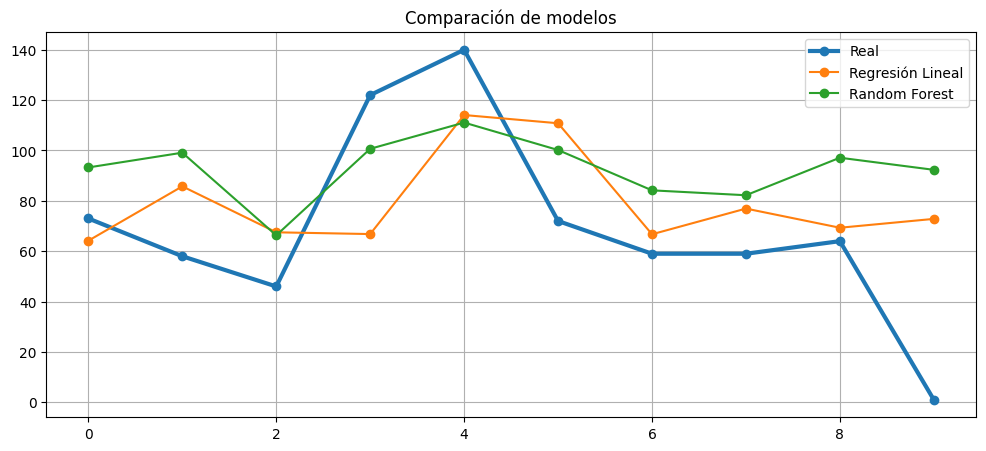

In [198]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values,
         marker="o",
         linewidth=3,
         label="Real")

plt.plot(y_pred_lr,
         marker="o",
         label="Regresión Lineal")

plt.plot(y_pred_rf,
         marker="o",
         label="Random Forest")

plt.legend()
plt.grid(True)

plt.title("Comparación de modelos")
plt.show()

Debido al reducido tamaño de la muestra histórica disponible (47 observaciones mensuales), los modelos de mayor complejidad no necesariamente mejoran el rendimiento predictivo. En este caso, el Random Forest presentó un peor desempeño que la regresión lineal, sugiriendo problemas de sobreajuste derivados de la escasez de datos de entrenamiento.

## 4.9 Modelo SARIMA

In [199]:
serie = demanda_mensual.set_index("Fecha")["Pedidos"]

In [200]:
serie.tail()

Fecha
2026-02-01    72
2026-03-01    59
2026-04-01    59
2026-05-01    64
2026-06-01     1
Name: Pedidos, dtype: int64

In [201]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [202]:
train_size = int(len(serie) * 0.8)

train = serie.iloc[:train_size]
test = serie.iloc[train_size:]

In [203]:
print(train.shape)
print(test.shape)

(40,)
(10,)


In [204]:
modelo_sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [205]:
resultado_sarima = modelo_sarima.fit(
    disp=False
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [206]:
print(resultado_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                            Pedidos   No. Observations:                   40
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -121.906
Date:                            Wed, 10 Jun 2026   AIC                            253.811
Time:                                    19:15:15   BIC                            260.291
Sample:                                         0   HQIC                           255.738
                                             - 40                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6407      0.442      1.450      0.147      -0.225       1.507
ma.L1         -0.9005      0.304   

In [207]:
print(resultado_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                            Pedidos   No. Observations:                   40
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -121.906
Date:                            Wed, 10 Jun 2026   AIC                            253.811
Time:                                    19:15:15   BIC                            260.291
Sample:                                         0   HQIC                           255.738
                                             - 40                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6407      0.442      1.450      0.147      -0.225       1.507
ma.L1         -0.9005      0.304   

In [208]:
pred_sarima = resultado_sarima.forecast(
    steps=len(test)
)

pred_sarima

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


40    107.955498
41    103.732949
42    107.008297
43    204.761994
44    210.758554
45    151.250372
46    136.547685
47    122.525705
48    120.853273
49    111.260104
Name: predicted_mean, dtype: float64

In [209]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

r2_sarima = r2_score(test, pred_sarima)

mae_sarima = mean_absolute_error(
    test,
    pred_sarima
)

rmse_sarima = np.sqrt(
    mean_squared_error(
        test,
        pred_sarima
    )
)

print("R² =", r2_sarima)
print("MAE =", mae_sarima)
print("RMSE =", rmse_sarima)

R² = -2.784742263813434
MAE = 68.26544296120348
RMSE = 71.14146993745544


In [210]:
df["Semana"] = df["Fecha Compra"].dt.to_period("W")

demanda_semanal = (
    df.groupby("Semana")
      .size()
      .reset_index(name="Pedidos")
)

print(demanda_semanal.shape)

(199, 2)


# 5. Predicción semanal de la demanda

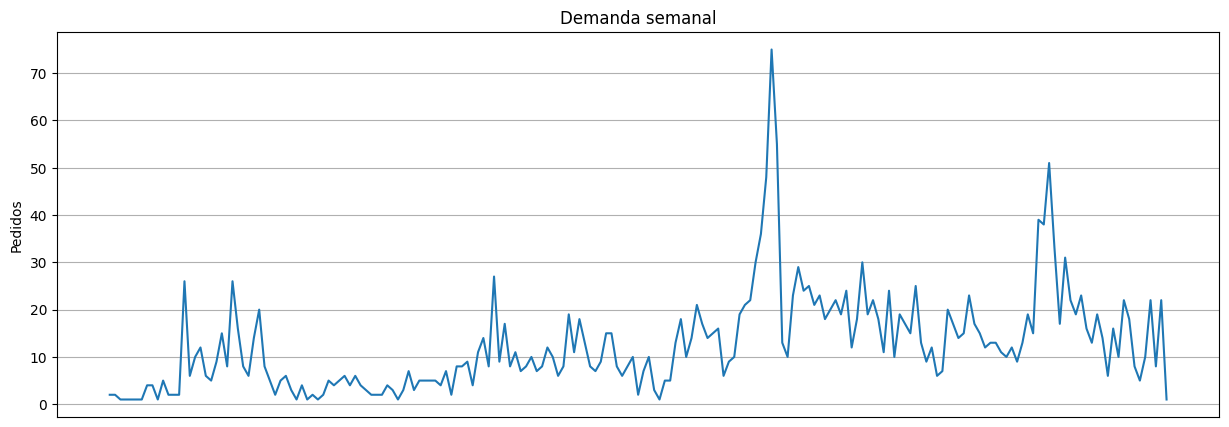

In [211]:
plt.figure(figsize=(15,5))

plt.plot(
    demanda_semanal["Semana"].astype(str),
    demanda_semanal["Pedidos"]
)

plt.title("Demanda semanal")
plt.ylabel("Pedidos")
plt.xticks([])
plt.grid(True)

plt.show()

In [212]:
demanda_semanal["Pedidos"].describe()

count    199.000000
mean      12.567839
std       10.444861
min        1.000000
25%        5.000000
50%       10.000000
75%       18.000000
max       75.000000
Name: Pedidos, dtype: float64

* Media: 12.57 pedidos/semana
* Mediana: 10 pedidos/semana
* Q3: 18 pedidos/semana
* Máximo: 75 pedidos/semana

## 5.1 Construcción de la serie temporal semanal

In [213]:
demanda_semanal["Fecha"] = (
    demanda_semanal["Semana"]
    .dt.start_time
)

serie_semanal = demanda_semanal.copy()

serie_semanal.head()

,Semana,Pedidos,Fecha
0,2022-03-28/2022-04-03,2,2022-03-28
1,2022-04-04/2022-04-10,2,2022-04-04
2,2022-04-25/2022-05-01,1,2022-04-25
3,2022-05-16/2022-05-22,1,2022-05-16
4,2022-06-27/2022-07-03,1,2022-06-27


## 5.2 Variables temporales

In [214]:
serie_semanal["lag_1"] = serie_semanal["Pedidos"].shift(1)
serie_semanal["lag_2"] = serie_semanal["Pedidos"].shift(2)
serie_semanal["lag_4"] = serie_semanal["Pedidos"].shift(4)
serie_semanal["lag_8"] = serie_semanal["Pedidos"].shift(8)

serie_semanal["Año"] = serie_semanal["Fecha"].dt.year
serie_semanal["Mes"] = serie_semanal["Fecha"].dt.month
serie_semanal["Semana_Año"] = serie_semanal["Fecha"].dt.isocalendar().week

In [215]:
X = serie_semanal[
    [
        "lag_1",
        "lag_2",
        "lag_4",
        "lag_8",
        "Mes",
        "Semana_Año"
    ]
]

In [216]:
#Revisamos nulos
serie_semanal.isnull().sum()

Semana        0
Pedidos       0
Fecha         0
lag_1         1
lag_2         2
lag_4         4
lag_8         8
Año           0
Mes           0
Semana_Año    0
dtype: int64

In [217]:
serie_semanal = serie_semanal.dropna()

In [218]:
serie_semanal.shape

(191, 10)

## 5.3 Definición de variables predictoras (X) y variable objetivo (y)

In [219]:
X = serie_semanal[
    [
        "lag_1",
        "lag_2",
        "lag_4",
        "lag_8",
        "Mes",
        "Semana_Año"
    ]
]

y = serie_semanal["Pedidos"]

In [220]:
print(X.shape)
print(y.shape)

X.head()

(191, 6)
(191,)


,lag_1,lag_2,lag_4,lag_8,Mes,Semana_Año
8,4.0,1.0,1.0,2.0,9,38
9,4.0,4.0,1.0,2.0,9,39
10,1.0,4.0,1.0,1.0,10,40
11,5.0,1.0,4.0,1.0,10,41
12,2.0,5.0,4.0,1.0,10,42


Se seleccionaron como variables predictoras los retardos de una, dos, cuatro y ocho semanas, así como variables de calendario (mes y semana del año), con el objetivo de capturar patrones temporales y estacionales en la demanda. La variable objetivo corresponde al número de pedidos registrados cada semana.

## 5.4 División temporal entrenamiento/prueba

In [221]:
train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [222]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (152, 6)
X_test: (39, 6)
y_train: (152,)
y_test: (39,)


In [223]:
#Verificamos corte temporal
serie_semanal.iloc[:train_size][["Fecha"]].tail()

,Fecha
155,2025-08-04
156,2025-08-11
157,2025-08-18
158,2025-08-25
159,2025-09-01


In [224]:
serie_semanal.iloc[train_size:][["Fecha"]].head()

,Fecha
160,2025-09-08
161,2025-09-15
162,2025-09-22
163,2025-09-29
164,2025-10-06


## 5.5 Modelo de Regresión Lineal semanal

In [225]:
#Entrenamiento
from sklearn.linear_model import LinearRegression

modelo_lr_sem = LinearRegression()

modelo_lr_sem.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [226]:
#Predicción
y_pred_lr_sem = modelo_lr_sem.predict(
    X_test
)

In [227]:
#Evaluación
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

r2 = r2_score(
    y_test,
    y_pred_lr_sem
)

mae = mean_absolute_error(
    y_test,
    y_pred_lr_sem
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr_sem
    )
)

print("R² =", r2)
print("MAE =", mae)
print("RMSE =", rmse)

R² = 0.3314761924952794
MAE = 6.0288365970551
RMSE = 8.04699128130635


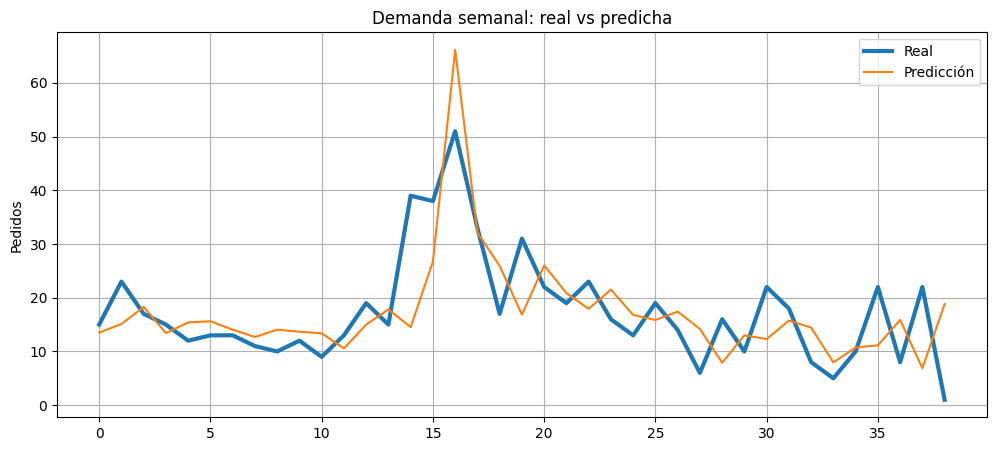

In [228]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    label="Real",
    linewidth=3
)

plt.plot(
    y_pred_lr_sem,
    label="Predicción"
)

plt.title("Demanda semanal: real vs predicha")
plt.ylabel("Pedidos")
plt.legend()
plt.grid(True)

plt.show()

In [229]:
#Importancia de los coeficientes
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_lr_sem.coef_
})

coeficientes.sort_values(
    by="Coeficiente",
    ascending=False
)

,Variable,Coeficiente
4,Mes,3.594323
0,lag_1,0.520616
2,lag_4,0.170337
3,lag_8,0.091229
1,lag_2,0.008575
5,Semana_Año,-0.761357


La frecuencia temporal utilizada tiene un impacto directo sobre el rendimiento predictivo. Mientras que el modelo mensual disponía únicamente de 47 observaciones y obtenía un R² de 0,095, la agregación semanal incrementó el número de observaciones hasta 183, mejorando el poder explicativo del modelo hasta un R² de 0,33 y reduciendo significativamente los errores de predicción.

## 5.6 Modelo Random Forest semanal

In [230]:
# Entrenamiento
from sklearn.ensemble import RandomForestRegressor

modelo_rf_sem = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

modelo_rf_sem.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a